In [3]:
import h5py as h5
from utils import * 


filename = "jro20260217drifts.hdf5"


In [2]:
print(data.shape)
print(hei.shape)
print(t.shape)

(64, 288)
(64,)
(288,)


In [4]:
import matplotlib.pyplot as plt 
import os 


listdir = os.listdir("./data")
fig = plt.figure(figsize=(16,9),dpi=90)

figs_save = "./figs"

if not os.path.isdir(figs_save):
    os.makedirs(figs_save)



<Figure size 1440x810 with 0 Axes>

In [10]:
    
for file in sorted(listdir):

    try:
        t,h,data = load_file(os.path.join("./data",file))


        print(h[0],h[-1])
    except:
        pass

45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
105.0 900.0
105.0 900.0
105.0 900.0
105.0 900.0
105.0 900.0
105.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0 900.0
45.0

In [6]:
    
for file in sorted(listdir):

    try:

        ### time in LT
        t,h,data = load_file(os.path.join("./data",file))
        
        fig.clf()
        ax = fig.add_subplot(1,1,1)
        vmax = numpy.nanpercentile(data,70)
       
        cc = ax.pcolormesh(t,h,data,cmap='jet',vmin=0,vmax=vmax, )
    
        fname = os.path.join(figs_save,file.split(".")[0] + ".png")
        fig.tight_layout()
        ax.set_ylim(220,900)
    
        
        fig.savefig(fname,dpi=60)
    ### eliminar si hay menos del 50% de datos entre el rango de 6 am a 6 pm 
    
    except Exception as e:

        print(file,e)


jro20250121drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250122drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250123drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250124drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250125drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250126drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250127drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250128drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250129drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250130drifts.hdf5 "Unable to synchronously open object (object 'range' doesn't exist)"
jro20250131drifts.hdf5 "Unable to synchronously open object (object 'range' does

In [6]:
import os
import numpy as np
import pandas as pd

TIME_FREQ = "5min"
HEIGHT_STEP = 15

TIME_TOL = pd.Timedelta("2.5min")
HEIGHT_TOL = HEIGHT_STEP / 2

records = []

for file in sorted(listdir):

    try:

        t, h, data = load_file(
            os.path.join("./data", file)
        )

        t = pd.to_datetime(t)

        T, H = np.meshgrid(t, h)

        df_tmp = pd.DataFrame({
            "time": T.ravel(),
            "height": H.ravel(),
            "value": data.ravel()
        })

        records.append(df_tmp)

    except Exception as e:

        print(f"Error en {file}: {e}")

df = pd.concat(records, ignore_index=True)

# Asignar a la grilla deseada
df["time_bin"] = df["time"].dt.round(TIME_FREQ)

df["height_bin"] = (
    np.round(df["height"] / HEIGHT_STEP)
    * HEIGHT_STEP
)

# Calcular errores de asignación
time_error = (
    df["time"] - df["time_bin"]
).abs()

height_error = (
    df["height"] - df["height_bin"]
).abs()

# Mantener sólo puntos suficientemente cercanos
df = df[
    (time_error <= TIME_TOL)
    &
    (height_error <= HEIGHT_TOL)
]

# Si varios puntos caen en la misma celda, promediar
df = (
    df.groupby(
        ["time_bin", "height_bin"],
        as_index=False
    )["value"]
    .mean()
)

df = df.rename(
    columns={
        "time_bin": "time",
        "height_bin": "height"
    }
)

# Crear grilla completa
time_grid = pd.date_range(
    df["time"].min(),
    df["time"].max(),
    freq=TIME_FREQ
)

height_grid = np.arange(
    df["height"].min(),
    df["height"].max() + HEIGHT_STEP,
    HEIGHT_STEP
)

full_grid = pd.MultiIndex.from_product(
    [time_grid, height_grid],
    names=["time", "height"]
)

# Reindexar para que aparezcan los faltantes como NaN
df_final = (
    df.set_index(["time", "height"])
      .reindex(full_grid)
      .reset_index()
)

print(df_final.head())

Error en jro20250121drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250122drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250123drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250124drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250125drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250126drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250127drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250128drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250129drifts.hdf5: "Unable to synchronously open object (object 'range' doesn't exist)"
Error en jro20250130drifts.hdf5: "Unable to synchronously open object (object 'ran

In [14]:
df.head(-5)

,time,height,value
0,1994-09-29 14:00:00,45.0,0.932
1,1994-09-29 14:00:00,60.0,1.515
2,1994-09-29 14:00:00,75.0,1.514
3,1994-09-29 14:00:00,90.0,1.536
4,1994-09-29 14:00:00,105.0,0.972
...,...,...,...
9907233,2024-05-17 07:55:00,1305.0,0.000
9907234,2024-05-17 07:55:00,1320.0,0.000
9907235,2024-05-17 07:55:00,1335.0,0.000
9907236,2024-05-17 07:55:00,1350.0,0.010


t: 216
h: 40
data: (40, 216)


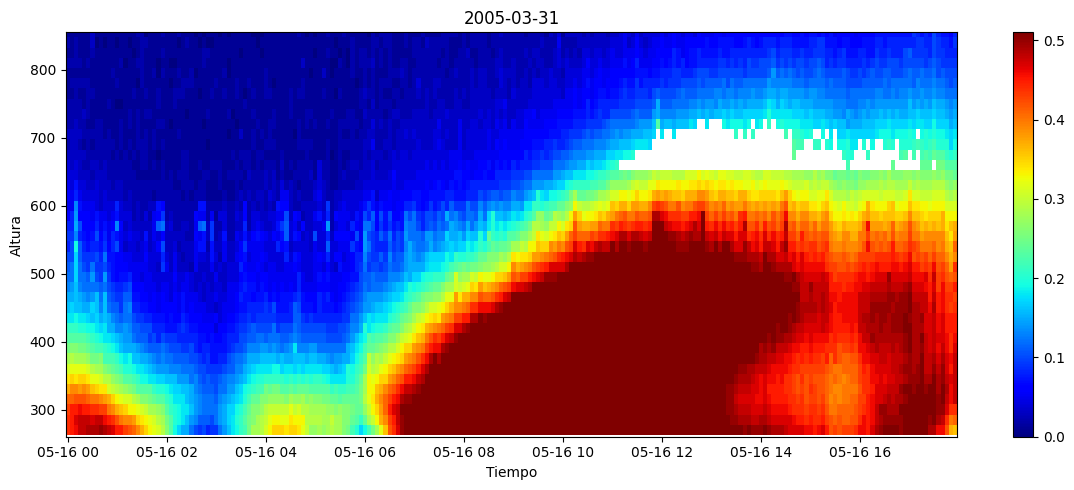

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------
# FECHA A GRAFICAR
# ----------------------------------

fecha_init = "2005-03-31"
fecha_init = "2024-05-16"
fecha_fin = fecha_init + " 23:59:59.999999"
 
fecha_init = "2024-05-16" + " 00:00:00.0"
fecha_fin = fecha_init + " 17:59:00.0"

t,h,data = retrive_data(df_final,fecha_init,fecha_fin)

# Verificación opcional
print("t:", len(t))
print("h:", len(h))
print("data:", data.shape)

# ----------------------------------
# PLOT
# ----------------------------------

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 1, 1)
vmax = np.nanpercentile(data, 85)

cc = ax.pcolormesh(
    t,
    h,
    data,
    cmap="jet",
    vmin=0,
    vmax=vmax,
    shading="auto"
)

fig.colorbar(cc, ax=ax)

ax.set_ylim(260, 855)

ax.set_xlabel("Tiempo")
ax.set_ylabel("Altura")

ax.set_title(fecha)

fig.tight_layout()

plt.show()

In [56]:
d_horas = int(((18 - 0) // 18) // (1/12))# cada 3 horas 
d_rango = int(((900 - 250) // 4) // 15 )## tres partchs en altura

print(d_horas,d_rango)

12 10


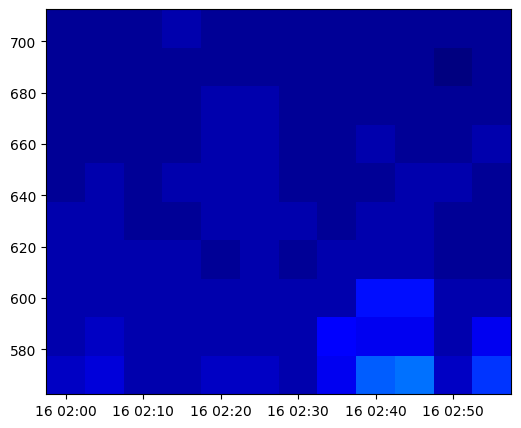

In [60]:


tt,hh,patch,_,_,_ = patchs[10]
        
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1)
vmax = np.nanpercentile(data, 85)

cc = ax.pcolormesh(
    tt,
    hh,
    patch,
    cmap="jet",
    vmin=0,
    vmax=vmax,
    shading="auto"
)


In [65]:
from datetime import datetime 

time_init = datetime(1994,9,29)
i=0
while 1:

    
    tmp = time_init + relativedelta(days=i)

    tomorrow = tmp + relativedelta(days=1)
    ### verifcamos si existe al menos el 50% de datos al siguiente dia entre 00-06 LT 
    ### para ver si hay Spread-F
    string_tomorrow = f"{tomorrow.year}-{tomorrow.month}-{tomorrow.day}"
    string_today = f"{tmp.year}-{tmp.month}-{tmp.day}"

    i_t = f"{string_tomorrow} 00:00:00.0"
    f_t = f"{string_tomorrow} 05:59:00.0"
    _,_,data = retrive_data(df_final,i_t,f_t)
 
    nans = numpy.count_nonzero(numpy.isnan(data))
    total = numpy.shape(numpy.ravel(data))[0]

    if nans>total*0.5:
 
        print("Saltando el dia por insuficiencia de datos del dia posterior:", string_today)
        i = i + 1 
        continue
    ### validamos si hay suficiente cantidad de datos el dia de hoy
    ### al menos el 50% en el rango de 8 a 18 lT
    
    i_t = f"{string_today} 08:00:00.0"
    f_t = f"{string_today} 17:59:00.0"
    _,_,data = retrive_data(df_final,i_t,f_t)

    nans = numpy.count_nonzero(numpy.isnan(data))
    total = numpy.shape(numpy.ravel(data))[0]   

    if nans>total*0.5:
 
        print("Saltando el dia por insuficiencia de datos del dia actual:", string_today)
        i = i + 1 
        continue

    figs_path = os.path.join(".","paths_check")
    
    if not os.path.isdir(figs_path):
        os.makedirs(figs_path)

        
    i_t = f"{string_today} 08:00:00.0"
    f_t = f"{string_tomorrow} 17:59:00.0"
    t,h,data = retrive_data(df_final,i_t,f_t)

    
    fig = plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(1, 1, 1)
    vmax = np.nanpercentile(data, 85)
    
    cc = ax.pcolormesh(
        t,
        h,
        data,
        cmap="jet",
        vmin=0,
        vmax=vmax,
        shading="auto"
    )
    
    fig.colorbar(cc, ax=ax)
    
    ax.set_ylim(260, 855)
    
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Altura")
    
    ax.set_title(fecha)
    
    fig.tight_layout()

    filename = f"{string_today}.png"
    fpath = os.path.join(figs_path,filename)
    fig.save_fig(fpath,dpi=90)

    print("Se guardó el dia de:",string_today)

    i = i +1 

Saltando el dia por insuficiencia de datos del dia posterior: 1994-9-29
Saltando el dia por insuficiencia de datos del dia posterior: 1994-9-30
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-1
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-2
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-3
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-4
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-5
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-6
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-7
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-8
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-9
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-10
Saltando el dia por insuficiencia de datos del dia posterior: 1994-10-11
Saltando el dia por insuficiencia de datos del dia posterior: 

KeyboardInterrupt: 

In [32]:
from scipy import stats


filename = ""
for filename in ["./data/jro19941001_drifts.001.hdf5",
                 "./data/jro19960124_drifts.001.hdf5",
                 "./data/jro19980716_drifts.001.hdf5",
                 "./data/jro20011212_drifts.001.hdf5",
                 "./data/jro20190102drifts.001.hdf5"]:
    
    with h5.File(filename,'r') as f:
    
        height = f["/Data/Array Layout/range"][:]
        tm = f["/Data/Array Layout/timestamps"][:]
    
        dh = stats.mode(height[1:] - height[:-1])
        dt = stats.mode(tm[1:] - tm[:-1])
        print(40*"-")
        print(f"file: {filename}")
        
        print(f"dH: {dh.mode} km")
        print(f"H max: {max(height)}")
        print(f"H min: {min(height)}")
        print(f"dT: {dt.mode} sec")
              
        #print(f["/Data/Array Layout/2D Parameters"].keys() )
        #print(f["/Data/Array Layout/range"][:] )
        #print()

----------------------------------------
file: ./data/jro19941001_drifts.001.hdf5
dH: 15.0 km
H max: 900.0
H min: 45.0
dT: 300 sec
----------------------------------------
file: ./data/jro19960124_drifts.001.hdf5
dH: 15.0 km
H max: 900.0
H min: 45.0
dT: 300 sec
----------------------------------------
file: ./data/jro19980716_drifts.001.hdf5
dH: 15.0 km
H max: 900.0
H min: 45.0
dT: 300 sec
----------------------------------------
file: ./data/jro20011212_drifts.001.hdf5
dH: 15.0 km
H max: 900.0
H min: 45.0
dT: 300 sec
----------------------------------------
file: ./data/jro20190102drifts.001.hdf5
dH: 15.0 km
H max: 945.0
H min: 0.0
dT: 300 sec


In [ ]:

def search_time(time,time_search):

    threshold = 
    
    dt = [time_search - x for x in time ]


def resize_and_prepare_data(data,time,height,hmin,hmax,tmin:int,tmax:int,size=(600,600)):
    resolution_time_data = 5 ## 5 min 
    resolution_height_data = 15 ### 15 kin
    ### considerando de 8 a 18 LT 
    w,h = size 
    time_size_patch =  w/(tmax-tmin)
    height_size_patch = h/(hmax-hmin)
    ## tmin in hours
    ## tmax in hours
    
    array = deepcopy(data)

    dt = time[len(time)//2]
    year,month,day = dt.year,dt.month,dt.day

    init_time = datetime(year,month,day,tmin,0,0) ## date min
    fin_time = datetime(year,month,day,tmax,0,0) ## date max

    i=0
    while 1:

        tmp_time = init_time + relativedelta(minutes=i*5)

        ind_time = search_time(time,tmp_time)
        i = i + 1 
    

    
    